In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import altair as alt
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')
w = pd.read_csv('ws.csv')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps', 'Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (cm)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict1 = {k: v for k, v in zip(keys, values)}
dict1

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (cm)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [7]:
a = melt_df_list_timed[2].copy()

In [8]:
# tab:blue : #1f77b4
# tab:orange : #ff7f0e
# tab:green : #2ca02c
# tab:red : #d62728
# tab:purple : #9467bd
# tab:brown : #8c564b
# tab:pink : #e377c2
# tab:gray : #7f7f7f
# tab:olive : #bcbd22
# tab:cyan : #17becf

# Violinplots

In [9]:
# fig = px.violin(a.loc[a.Name!='o1'], x='Sex', y='val', facet_row='Group', color='Test',
#                 hover_name=a.loc[a.Name!='o1'].Name,
#                 category_orders={'Test' : ['initial', 'final']},
#                 color_discrete_sequence=['darkorange', 'darkseagreen'],
#                 violinmode='group', template='simple_white',
#                 width=750, height=500, box=True)

# fig.update_traces(marker_line_color='black',
#                   marker_size=4.5, 
#                   marker_line_width=0.3,
#                   points='outliers', hoverinfo="x",
#                   jitter=1,
#                   box_fillcolor='rgba(0,0,0,0.3)',
#                   meanline_color='black',
#                   bandwidth=0.2)

# fig.update_layout(violingap=0, violingroupgap=0.4, 
#                   margin=dict(l=20, r=20, t=20, b=20),
#                   legend_x=0.45)

# fig.data[0].box.fillcolor='rgba(255,0,0,0.4)'
# fig.data[1].box.fillcolor='rgba(255,255,0,0.4)'
# fig.data[2].box.fillcolor='rgba(0,0,255,0.4)'
# fig.data[3].box.fillcolor='rgba(255,0,255,0.4)'
# fig.update_xaxes(ticks='inside',title_standoff=0)
# fig.update_yaxes(ticks='inside',title_standoff=0)
# # x grouping variable won't get separate traces
# fig.show()

In [10]:
# violin = alt.Chart(width=100).transform_density(
#     density='val',
#     as_=['val', 'density'],
#     extent=[-2, 15], # violins begin below 0
#     groupby=['groups_3']
# ).mark_area(orient='horizontal').encode(
#     alt.X('density', type='quantitative',
#          scale=alt.Scale(nice=False,zero=False)) # no 0 or round number autoalign 
#         .stack('center')                         # like in steamograph
#         .impute(None)                            # only if you have nans
#         .title(None)
#         .axis(labels=False, values=[0], grid=False, ticks=False),
#     alt.Y(field='val', type='quantitative'),
#     alt.Color(field='groups_3', type='nominal')
# )

# boxplot = alt.Chart(width=100).mark_boxplot(
#     box={'cornerRadius':10}, # main box
#     median=True, # tick type
#     rule=True, # IQR/outliers black line
#     outliers=False, # mark_point
#     ticks=False, # end ticks
#     size=5,
#     color='black'
# ).encode(
#     alt.Y(field='val', type='quantitative').scale(domain=[-2,15])
# )
# alt.layer(violin, boxplot, data=a.loc[a.val.notna()]).facet(
#     alt.Column(field='groups_3', type='nominal')
#     .title('groups')
#     .sort(['B F initial', 'B F final', 'B M initial', 'B M final',
#            'J F initial', 'J F final', 'J M initial', 'J M final'])
# ).resolve_scale(x=alt.ResolveMode("independent")).configure_view(stroke=None).configure_facet(spacing=0)
# # independent x scale for boxplots to align with violins, stroke=None for no facet borders, spacing=0
# # you can also create two violins halfs separately by dropping .stack and 
# # inserting .transform_calculate(density="-datum.density")

In [11]:
# alt.Chart(a.loc[a.val.notna()]).mark_boxplot(
#     box={'cornerRadius':10}, # main box
#     median=True, # white line
#     rule=True, # IQR/outliers black line
#     outliers=False, # mark_point
#     ticks={'size':15}, # end ticks
#     size=15,
#     color='black'
# ).encode(
#     alt.X(field='Test', type='nominal').sort(['initial', 'final']),
#     alt.Y(field='val', type='quantitative').scale(domain=[0,15]),
#     column='Group:N',
#     row='Sex:N'
# ).properties(height=200, width=200)

# Scatter + trendline

In [12]:
# px.scatter(a.loc[a.val<20], x='time', y='val', color='Test',
#            trendline='expanding', # ols', 'lowess', 'rolling', 'expanding' or 'ewm'
#            template='plotly_white', opacity=0.5,
#            color_discrete_sequence=['tomato','darkseagreen']
#            ).update_traces(marker_size=5
#            ).update_layout(margin=dict(l=20, r=20, t=20, b=20), legend_x=0.9
#            ).update_xaxes(title_standoff=0,
#                           range=[0,60],
#                           ticks='inside',
#                           zerolinewidth = 3,
#                           showspikes=True,
#                           type='linear' # also log, date, (multi)category
#            ).update_yaxes(title_standoff=0,
#                           range=[0,16],
#                           visible=False,
#                           zerolinewidth = 3,
#                           showspikes=True,
#                           type='linear')

In [13]:
# base = alt.Chart(a).mark_point(opacity=0.2, size=20, clip=True).encode(
#     alt.X('time:Q').scale(domain=(0, 60)),
#     alt.Y('val:Q').scale(domain=(0, 8)),
#     alt.Color('Test:N'),
# ).properties(
#     width=1100,
#     height=300
# )

# base + base.transform_loess('time', 'val', groupby=['Test'], bandwidth=0.03).mark_line(size=4)

In [14]:
# base_lines = alt.Chart(a).mark_line(opacity=0.5, clip=True, size=1).encode(
#     alt.X('time:Q').scale(domain=(0,60)),
#     alt.Y('val:Q').scale(domain=(0,9)),
#     color = 'Test:N',
#     detail = 'Name:N',
#     order = 'Jump:O'
# ).properties(width=500, height=100)

# lines_mean = alt.Chart(a).mark_line(size=3, color='black', clip=True).encode(
#     alt.X('mean(time)'),
#     alt.Y('mean(val)').scale(domain=(0,9)),
#     alt.Color('Test:N'),
#     order = 'Jump:O'
# )

# chart = (base_lines + lines_mean).facet(
#     column="Sex:N",
#     row="Group:N"
# )
# chart

In [15]:
# alt.Chart(a).mark_errorband(extent="ci", borders=True).encode(
#     alt.X('mean(time)'),
#     alt.Y('mean(val)'),
#     alt.Color('Test:N'),
#     order = 'Jump:O',
# ).properties(width=1000, height=100)

# Histograms

In [16]:
# px.imshow(e.loc[:,1:169])

In [17]:
# px.imshow(w.loc[:,'1':].T)

# Spaghettiplots + mean + CI band

In [18]:
# px.line(melt_df_list[2].loc[melt_df_list[2].Name!='o1',:],
#         x='Jump', y='val', color='Name', line_group='Test', 
#         template='simple_white', line_shape='spline',
#         color_discrete_sequence=['green','tomato']
#         ).update_traces(line_width=1.5, opacity=0.4,
#         ).update_layout(margin=dict(l=20, r=20, t=20, b=20), height=350
#         ).update_xaxes(ticks='inside', title_standoff=0, showgrid=True,
#                        type='linear'
#         ).update_yaxes(ticks='inside', title_standoff=0, showgrid=True,
#                        range=[0,19],
#                        type='linear')

In [33]:
(
# alt.Chart(a, width=1200).mark_line(
#     size=1.5, opacity=0.2, clip=True, interpolate='basis'
#     ).encode(
#     alt.X('Jump:Q'),
#     alt.Y('val', type=('quantitative')).scale(domainMax=8),
#     alt.Color('Test:N'),
#     alt.Detail('Name:N'),
# ) +

# alt.Chart(a, width=1200).mark_line(size=5).encode(
#     alt.X('Jump:Q'),
#     alt.Y('mean(val)', type='quantitative'),
#     alt.Color('Test:N'),
# ) +

# alt.Chart(a, width=1200).mark_errorband(
#     extent='ci', borders=True,
#     ).encode(
#     alt.X('Jump:Q'),
#     alt.Y('mean(val):Q'),
#     alt.Color('Test:N'),
# )
)

()

(0.0, 170.0)

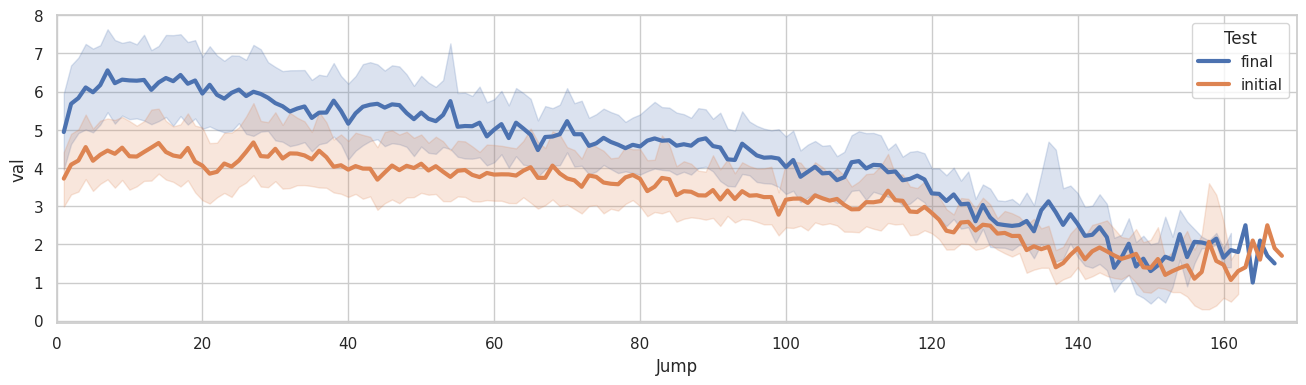

In [20]:
sns.set(rc={"figure.figsize":(16,4)})
sns.set_style('whitegrid')
sns.lineplot(a, x='Jump',y='val', hue='Test', errorbar='ci', lw=3).set_xlim(0,170)
# sns.lineplot(a, x='Jump',y='val', hue='Test',
#              units='Name', estimator=None,
#              lw=0.5, alpha=0.3, legend=False).set_ylim(0,8)

# Jointgrids

In [21]:
pd.merge(a, melt_df_list_timed[1], how='left', left_index=True, right_index=True, suffixes=['_e', '_c'])

,Name_e,Test_e,Group_e,Sex_e,NJumps_e,Mean_e,Jump_e,val_e,time_e,Name_c,Test_c,Group_c,Sex_c,NJumps_c,Mean_c,Jump_c,val_c,time_c
0,o1,final,J,F,122,4.324590,1,8.4,0.262,o1,final,J,F,122,0.309446,1,NaN,0.262
1,o2,final,B,M,135,4.351111,1,6.3,0.226,o2,final,B,M,135,0.261328,1,NaN,0.226
2,o3,final,J,F,105,9.558095,1,10.6,0.294,o3,final,J,F,105,0.294904,1,NaN,0.294
3,o4,final,B,F,122,6.707377,1,11.3,0.304,o4,final,B,F,122,0.264959,1,NaN,0.304
4,o5,final,J,M,104,10.629808,1,11.3,0.304,o5,final,J,M,104,0.284155,1,NaN,0.304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13515,o36,initial,B,M,135,2.478519,169,NaN,NaN,o36,initial,B,M,135,0.308284,169,NaN,NaN
13516,o37,initial,J,M,149,3.192617,169,NaN,NaN,o37,initial,J,M,149,0.244622,169,NaN,NaN
13517,o38,initial,J,M,133,2.611278,169,NaN,NaN,o38,initial,J,M,133,0.315848,169,NaN,NaN
13518,o39,initial,B,M,161,3.662112,169,NaN,NaN,o39,initial,B,M,161,0.202888,169,NaN,NaN


In [22]:
a['groups'] = 'empty'
for j in a.index:
    a.loc[j, 'groups'] = (str(a.loc[j,'Test']) + ' ' + str(a.loc[j,'Sex']))

In [23]:
# a['groups_3'] = 'empty'
# for j in a.index:
#     a.loc[j, 'groups_3'] = (str(a.loc[j,'Group']) + ' ' + str(a.loc[j,'Sex']) + ' ' + str(a.loc[j,'Test']))

In [24]:
# base = alt.Chart(pd.merge(a, melt_df_list_timed[1], how='left',
#                           left_index=True, right_index=True,
#                           suffixes=['_e', '_c']))\
#  .transform_filter(
#     (alt.datum.val_e < 20) & (alt.datum.val_c < 0.5)
# ).properties(height=300, width=300)

# base_bar = base.mark_bar(opacity=0.6, binSpacing=0)

# xscale = alt.Scale(domain=(0.1, 0.5))
# yscale = alt.Scale(domain=(0, 20))

# points = base.mark_circle(clip=True, opacity=0.2).encode(
#     alt.X("val_c").scale(xscale).title('Contact time (s)'),
#     alt.Y("val_e").scale(yscale).title('Elevation (cm)'),
#     alt.Color("Test_e:N").scale(domain=['initial', 'final'], range=['tomato','darkseagreen'])
#     .legend(orient='none', legendX=360, legendY=30)
# )

# top_hist = (
#     base_bar
#     .encode(
#         alt.X("val_c:Q")
#             # when using bins, the axis scale is set through
#             # the bin extent, so we do not specify the scale here
#             # (which would be ignored anyway)
#             .bin(maxbins=50, extent=xscale.domain).stack(None).title(""),
#         alt.Y("count()").stack(None).title(""),
#         alt.Color("Test_e:N"),
#     )
#     .properties(height=100)
# )

# right_hist = (
#     base_bar
#     .encode(
#         alt.Y("val_e:Q")
#             .bin(maxbins=50, extent=yscale.domain)
#             .stack(None)
#             .title(""),
#         alt.X("count()").stack(None).title(""),
#         alt.Color("Test_e:N"),
#     )
#     .properties(width=100)
# )

# top_hist & (points | right_hist)

In [25]:
# base = alt.Chart(pd.merge(a, melt_df_list_timed[1], how='left',
#                           left_index=True, right_index=True,
#                           suffixes=['_e', '_c']))\
#  .transform_filter(
#     (alt.datum.val_e < 20) & (alt.datum.val_c < 0.5)
# ).properties(height=400, width=400)

# base_bar = base.mark_bar(opacity=0.4, binSpacing=0)

# xscale = alt.Scale(domain=(0.16, 0.4))
# yscale = alt.Scale(domain=(0, 14))

# points = base.mark_point(clip=True, opacity=0.2).encode(
#     alt.X("val_c").scale(xscale).title('Contact time (s)'),
#     alt.Y("val_e").scale(yscale).title('Elevation (cm)'),
#     alt.Color("groups:N").legend(orient='none', legendX=450, legendY=30)
# )

# top_hist = (
#     base_bar
#     .encode(
#         alt.X("val_c:Q")
#             # when using bins, the axis scale is set through
#             # the bin extent, so we do not specify the scale here
#             # (which would be ignored anyway)
#             .bin(maxbins=50, extent=xscale.domain).stack(None).title(""),
#         alt.Y("count()").stack(None).title(""),
#         alt.Color("groups:N"),
#     )
#     .properties(height=100)
# )

# right_hist = (
#     base_bar
#     .encode(
#         alt.Y("val_e:Q")
#             .bin(maxbins=50, extent=yscale.domain)
#             .stack(None)
#             .title(""),
#         alt.X("count()").stack(None).title(""),
#         alt.Color("groups:N"),
#     )
#     .properties(width=100)
# )

# top_hist & (points | right_hist)

In [26]:
# base = alt.Chart(pd.merge(a, melt_df_list_timed[1], how='left',
#                           left_index=True, right_index=True,
#                           suffixes=['_e', '_c']))\
#  .transform_filter(
#     (alt.datum.val_e < 20) & (alt.datum.val_c < 0.5)
# ).properties(height=400, width=400)

# xscale = alt.Scale(domain=(0.16, 0.4))
# yscale = alt.Scale(domain=(1, 14))

# points = base.mark_square(clip=True, opacity=0.2).encode(
#     alt.X("val_c").scale(xscale).title('Contact time (s)'),
#     alt.Y("val_e").scale(yscale).title('Elevation (cm)'),
#     alt.Color("groups:N").legend(orient='none', legendX=450, legendY=30)
# )

# top_kde = base.mark_area(opacity=0.5, orient='vertical')\
#     .transform_density(
#         density='val_c',
#         groupby=['groups'],
#         as_=['val_c', 'density'],
#         extent=xscale.domain,
#         counts=True,
#         bandwidth=0.004
#     )\
#     .encode(
#         alt.X("val_c:Q").title(None),
#         alt.Y("density:Q").stack(None).title(""),
#         alt.Color("groups:N"),
#     )\
#     .properties(height=100)

# right_kde = base.mark_area(opacity=0.5, orient='horizontal')\
#     .transform_density(
#         density='val_e',
#         groupby=['groups'],
#         as_=['val_e', 'density'],
#         extent=yscale.domain,
#         counts=True,
#         bandwidth=0.2
#     )\
#     .encode(
#         alt.Y("val_e:Q")
#             .stack(None)
#             .title(""),
#         alt.X("density:Q").stack(None).title(""),
#         alt.Color("groups:N"),
#     )\
#     .properties(width=100)

# top_kde & (points | right_kde)